# Analyse de la Sécurité au Bénin via Topic Modeling
Ce notebook traite les données GDELT et les articles scrapés pour identifier 
les thématiques de sécurité dominantes en séparant l'anglais et le français.

In [26]:
import pandas as pd
import numpy as np
import os
import glob
import langdetect
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

from spacy.lang.en.stop_words import STOP_WORDS as en_stops
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stops

pd.set_option('display.max_colwidth', None)

PATH_RAW_ARTICLES = "../data/raw/articles/"
PATH_CLEAN_GDELT = "../data/clean/gdelt_benin_clean.csv"
PATH_OUTPUT = "../data/processed/dataset-with-topics.csv"
PATH_FR_TOPICS = "../data/processed/fr_topics.csv"
PATH_EN_TOPICS = "../data/processed/en_topics.csv"

## 1. Chargement, Fusion et Détection de la langue
On lie les fichiers `.txt` au CSV GDELT via l'ID de l'événement et on détecte la langue.

In [4]:
def load_and_merge():
    df_gdelt = pd.read_csv(PATH_CLEAN_GDELT)

    articles = []
    for filepath in glob.glob(os.path.join(PATH_RAW_ARTICLES, "*.txt")):
        event_id = os.path.basename(filepath).split('.')[0]
        try:
            with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                articles.append({
                    "GLOBALEVENTID": int(event_id),
                    "content": f.read().strip()
                })
        except ValueError:
            continue

    df_txt = pd.DataFrame(articles)
    merged_df = pd.merge(df_gdelt, df_txt, on="GLOBALEVENTID")
    print(f"Fusion terminée : {len(merged_df)} articles prêts à l'analyse.")
    return merged_df

df = load_and_merge()

def detect_lang(text):
    try:
        return langdetect.detect(text)
    except:
        return 'Unknown'

print("Détection des langues en cours...")
df['lang'] = df['content'].apply(detect_lang)

df['Topic_ID'] = -1
df['Topic_Name'] = "Non-classé"

Fusion terminée : 6468 articles prêts à l'analyse.
Détection des langues en cours...


## 2. Traitement du Corpus Anglophone
Génération du WordCloud et extraction des thèmes via BERTopic (modèle all-MiniLM-L6-v2).

In [5]:
df_en = df[df['lang'] == 'en'].copy()
en_docs = df_en['content'].fillna("").astype(str).tolist()

custom_web_noise_en = [
    'subscribe', 'minutes', 'news', 'punch', 'youtube', 'video', 'reports',
    'ago', 'hours', 'breaking', 'columns', 'daily', 'post', 'observer',
    'window', 'features', 'specials', 'nan', 'monday', 'read', 'said', 'will'
]
all_en_stops = list(en_stops) + custom_web_noise_en

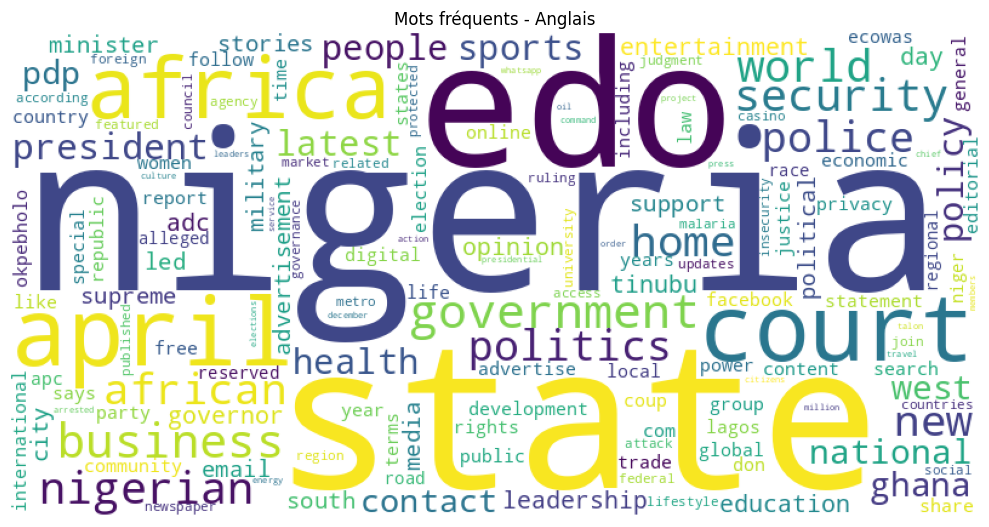

In [6]:
vectorizer_wc_en = CountVectorizer(
    stop_words=all_en_stops,
    max_df=0.85,
    min_df=10,
    max_features=500,
    token_pattern=r'(?u)\b[A-Za-z]{3,}\b'
)
wc_matrix_en = vectorizer_wc_en.fit_transform(en_docs)
words_dict_en = dict([(word, wc_matrix_en.sum(axis=0)[0, idx]) for word, idx in vectorizer_wc_en.vocabulary_.items()])

plt.figure(figsize=(10, 6))
plt.imshow(WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=150).generate_from_frequencies(words_dict_en))
plt.axis('off')
plt.title("Mots fréquents - Anglais")
plt.tight_layout()
plt.savefig('wordcloud_en.png')
plt.show()

In [31]:
vectorizer_bert_en = CountVectorizer(stop_words=all_en_stops, min_df=5, token_pattern=r'(?u)\b[A-Za-z]{3,}\b')
embedding_model_en = SentenceTransformer("all-MiniLM-L6-v2")

topic_model_en = BERTopic(
    embedding_model=embedding_model_en,
    vectorizer_model=vectorizer_bert_en,
    language="english",
    min_topic_size=10
)

topics_en, _ = topic_model_en.fit_transform(en_docs)
df_en['Topic_ID'] = topics_en
df_en['Topic_Name'] = df_en['Topic_ID'].apply(lambda x: topic_model_en.get_topic_info(x)['Name'].values[0] if x != -1 else "Bruit")

topic_model_en.get_topic_info().to_csv(PATH_EN_TOPICS, index=False)
topic_model_en.get_topic_info().head(30)[['Topic', 'Count', 'Name', 'Representation']]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Topic,Count,Name,Representation
0,-1,1105,-1_africa_state_benin_nigeria,"[africa, state, benin, nigeria, government, police, african, business, world, people]"
1,0,262,0_court_malaria_race_edo,"[court, malaria, race, edo, judgment, pdp, leadership, turaki, eliminate, day]"
2,1,245,1_coup_talon_military_benin,"[coup, talon, military, benin, soldiers, president, ecowas, attempt, attempted, sunday]"
3,2,140,2_casino_investigations_data_opens,"[casino, investigations, data, opens, online, special, governorship, click, nigeria, report]"
4,3,91,3_okpebholo_governor_obaseki_edo,"[okpebholo, governor, obaseki, edo, state, administration, government, projects, sun, pdp]"
5,4,82,4_party_apc_pdp_edo,"[party, apc, pdp, edo, state, sun, chairman, congress, election, april]"
6,5,78,5_efcc_fraud_court_alleged,"[efcc, fraud, court, alleged, prosecution, crimes, commission, money, financial, internet]"
7,6,77,6_drug_ndlea_cannabis_illicit,"[drug, ndlea, cannabis, illicit, ofoyeju, drugs, arrests, trafficking, arrested, traffickers]"
8,7,71,7_police_kidnappers_kidnapped_ransom,"[police, kidnappers, kidnapped, ransom, victims, rescue, command, rescued, edo, operatives]"
9,8,66,8_ghana_password_editors_pick,"[ghana, password, editors, pick, execution, energy, africa, african, claimant, judgment]"


In [ ]:
topic_model_en.visualize_topics()

In [18]:
new_docs = ["""The Conflict Over Nigeria’s Returned Treasures
Western museums are returning the Benin Bronzes 
— priceless items looted during colonialism — 
to Nigeria, but political infighting has jeopardized the ability 
to display and maintain the masterpieces. Our reporter, Alex Marshall,
traveled to Nigeria to see some of the Bronzes."""]

# Prédire les topics et les probabilités
detected_topics, detected_probs = topic_model_en.transform(new_docs)

print(topic_model_en.get_topic_info().loc[detected_topics[0], 'Name'])

2_nigeria_state_adc_president


## 3. Traitement du Corpus Francophone
Génération du WordCloud et extraction des thèmes via BERTopic (modèle sentence-camembert-base).

In [19]:
df_fr = df[df['lang'] == 'fr'].copy()
fr_docs = df_fr['content'].fillna("").astype(str).tolist()

bruit_web_massif_fr = [
    'lire', 'suite', 'article', 'publié', 'abonnez', 'partager', 'publicité',
    'newsletter', 'droits', 'réservés', 'savoir', 'plusoffres', 'répondre',
    'courriel', 'tribune', 'minutes', 'accueil', 'connexion', 'inscription',
    'mot', 'passe', 'connecter', 'connectez', 'utilisateur', 'oublié', 'bienvenue',
    'fenêtre', 'cookies', 'envoyer', 'annuler', 'email', 'abonner', 'premium',
    'com', 'org', 'net', 'https', 'javascript', 'thème', 'section', 'contenus',
    'app', 'infos', 'galerie', 'voir', 'fact', 'imprimer', 'corriger', 'mois',
    'heures', 'octobre', 'septembre', 'novembre', 'mai', 'avril', 'décembre',
    'agence', 'presse', 'actualité', 'nouvelle', 'propos', 'contact', 'site',
    'and', 'for', 'the', 'with', 'your', 'online', 'school', 'learning', 'message',
    'cet', 'cette', 'tout', 'tous', 'plus', 'faire', 'avoir', 'être', 'comme',
    'très', 'aussi', 'bien', 'sans', 'leur', 'leurs', 'mis', 'été'
]
all_fr_stops = list(fr_stops) + bruit_web_massif_fr

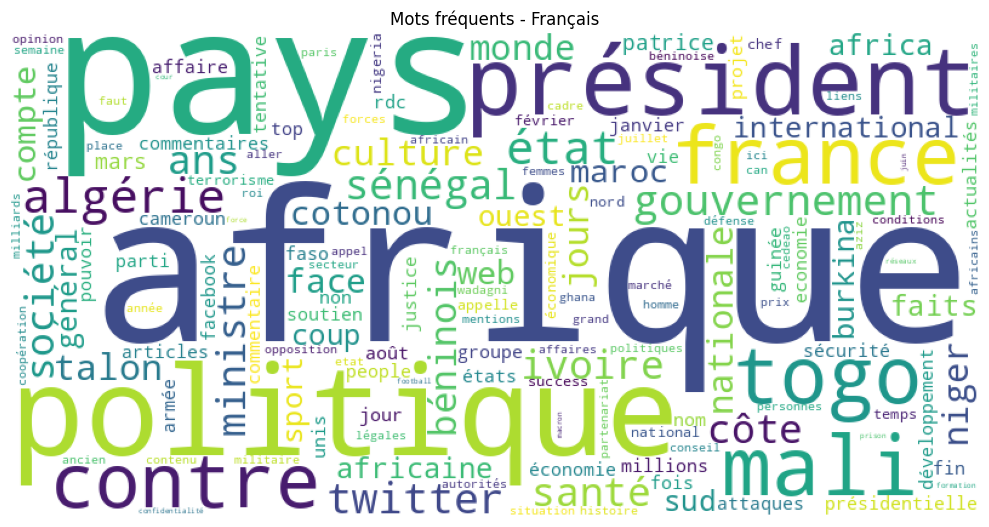

In [21]:
vectorizer_wc_fr = CountVectorizer(
    stop_words=all_fr_stops,
    max_df=0.85,
    min_df=5,
    max_features=500,
    token_pattern=r'(?u)\b[A-Za-zÀ-ÿ]{3,}\b'
)
wc_matrix_fr = vectorizer_wc_fr.fit_transform(fr_docs)
words_dict_fr = dict([(word, wc_matrix_fr.sum(axis=0)[0, idx]) for word, idx in vectorizer_wc_fr.vocabulary_.items()])

plt.figure(figsize=(10, 6))
plt.imshow(WordCloud(width=800, height=400, background_color='white', max_words=150).generate_from_frequencies(words_dict_fr))
plt.axis('off')
plt.title("Mots fréquents - Français")
plt.tight_layout()
plt.savefig('wordcloud_fr.png')
plt.show()

In [22]:
vectorizer_bert_fr = CountVectorizer(stop_words=all_fr_stops, min_df=5, token_pattern=r'(?u)\b[A-Za-zÀ-ÿ]{3,}\b')
embedding_model_fr = SentenceTransformer("dangvantuan/sentence-camembert-base")

topic_model_fr = BERTopic(
    embedding_model=embedding_model_fr,
    vectorizer_model=vectorizer_bert_fr,
    language="french",
    min_topic_size=10
)

topics_fr, _ = topic_model_fr.fit_transform(fr_docs)
df_fr['Topic_ID'] = topics_fr
df_fr['Topic_Name'] = df_fr['Topic_ID'].apply(lambda x: topic_model_fr.get_topic_info(x)['Name'].values[0] if x != -1 else "Bruit")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [24]:
topic_model_fr.get_topic_info().to_csv(PATH_FR_TOPICS, index=False)
topic_model_fr.get_topic_info().head(10)[['Topic', 'Count', 'Name', 'Representation']]

,Topic,Count,Name,Representation
0,-1,186,-1_algérie_afrique_maroc_découvrez,"[algérie, afrique, maroc, découvrez, abidjan, côte, ivoire, millions, marché, france]"
1,0,583,0_bénin_politique_web_pays,"[bénin, politique, web, pays, faits, aziz, société, président, fois, nom]"
2,1,118,1_france_min_santé_monde,"[france, min, santé, monde, bénin, culture, newsletters, politique, point, abus]"
3,2,117,2_bénin_gouvernement_recrutement_clôture,"[bénin, gouvernement, recrutement, clôture, profit, république, appel, projet, ministre, candidature]"
4,3,111,3_local_education_you_afrique,"[local, education, you, afrique, commentaires, address, this, sport, politique, sénégal]"
5,4,86,4_twitter_togo_afrique_président,"[twitter, togo, afrique, président, top, jours, africa, ivoire, août, mali]"
6,5,74,5_sénégal_groupe_info_politique,"[sénégal, groupe, info, politique, bénin, compte, partenaires, afrique, actu, santé]"
7,6,55,6_chine_china_bénin_béninois,"[chine, china, bénin, béninois, afrique, international, source, favoris, french, haut]"
8,7,50,7_mali_niger_sélectionneur_national,"[mali, niger, sélectionneur, national, nation, news, aigles, poste, sahel, face]"
9,8,43,8_afrique_guinée_bénin_afrik,"[afrique, guinée, bénin, afrik, soudan, pays, parti, sud, démocrates, opposition]"


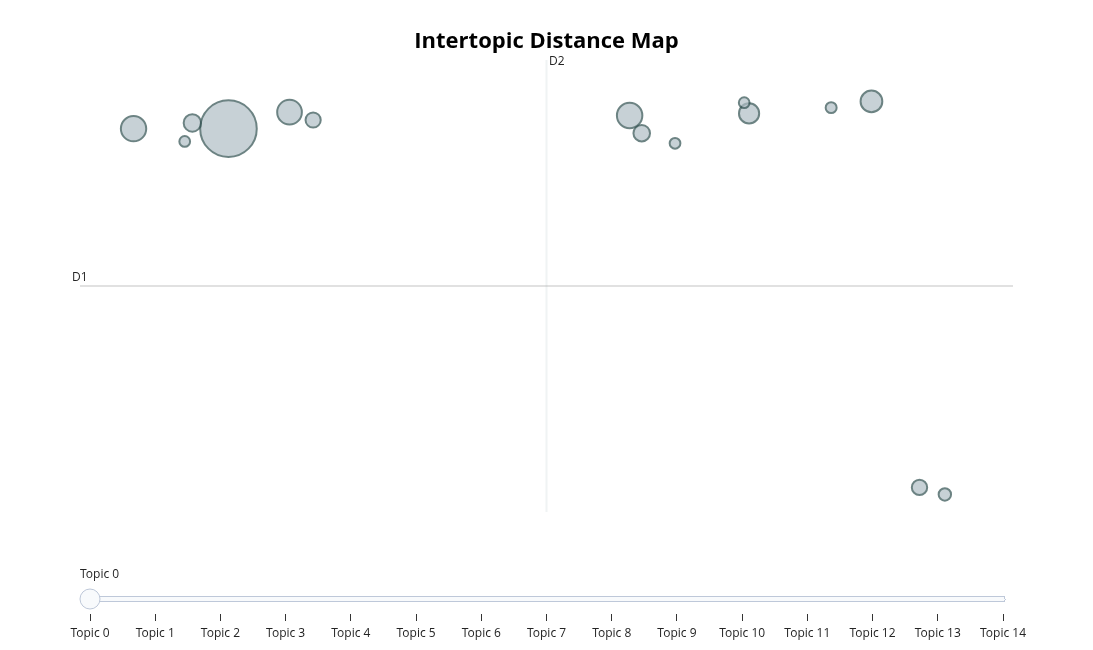

In [39]:
topic_model_fr.visualize_topics()

## 4. Exportation

In [27]:
df.set_index('GLOBALEVENTID', inplace=True)
df_en.set_index('GLOBALEVENTID', inplace=True)
df_fr.set_index('GLOBALEVENTID', inplace=True)

df.update(df_en[['Topic_ID', 'Topic_Name']])
df.update(df_fr[['Topic_ID', 'Topic_Name']])

df.reset_index(inplace=True)

# Colonnes à exporter
colonnes_export = [
    'GLOBALEVENTID', 'SQLDATE', 'Actor1Code', 'Actor1Name', 'Actor2Code', 'Actor2Name',
    'EventCode', 'GoldsteinScale', 'QuadClass', 'NumMentions', 'AvgTone',
    'SOURCEURL', 'lang', 'Topic_ID', 'Topic_Name', 'content'
]

colonnes_existantes = [col for col in colonnes_export if col in df.columns]
df_export = df[colonnes_existantes].copy()

df_export.to_csv(PATH_OUTPUT)
print(f"Exportation terminée avec succès dans : {PATH_OUTPUT}")

KeyError: "None of ['GLOBALEVENTID'] are in the columns"

In [38]:
topic_model_en.save("../models/bertopic_model_en", serialization="safetensors", save_embedding_model=True)
topic_model_fr.save("../models/bertopic_model_fr", serialization="safetensors", save_embedding_model=True)